# Edge detection

In this lab exercise, you will look at applying edge detectors to images and comparing two different methods. You will also learn how to write a function in Python and evaluate the difference when using an approximation for the calculation of a parameter.

At this stage, we will assume that you are able to use Python, and understand its basic use. **You are asked to write a short (no more than 2 pages) report of your work**, answering specific questions, and showing example images. This work is not assessed (it will not count towards your module mark) but you will get formative feedback.

Three images are provided for the assignment, './cameraman.png','./circle.jpg','./mri2.jpg', please feel free to use **any of them** to explore the tasks. Following we take './cameraman.png' as an example.

### Introduction

First we will cover some basics regarding Python and Image Manipulation.

The first step is importing the required packages. In this assignment we will be using [scikit-image](https://scikit-image.org/), [MatPlotLib](https://matplotlib.org/) and [Numpy](https://numpy.org/). Check that your environment is configured correctly by running the section below. 

In [5]:
# Imports
import skimage
import scipy
from matplotlib import pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter, convolve
import os

os.getcwd()

'/jupyter/work/Computer-Vision-and-Imaging-Lab/New_lab/W4Lab_Students2025_Canvas'

In order to load images we use the [imread](https://scikit-image.org/docs/stable/user_guide/getting_started.html) function which is part of scikit-image. Images can be displayed using the show_rgb_image helper function. Read through this function to understand how it works. We can also see the raw image data by printing the variable using ```print```. As can be seen, by default in Skimage image pixels are represented as bytes with a range of 0-255. Depending on the processing methods, consider a normalised version of the image in the [0.0, 1.0] range by dividing the image by its maximum intensity value.

**Important** Make sure your working directory is the same containing your Jupyter lab file (Using import os and os.getcwd())

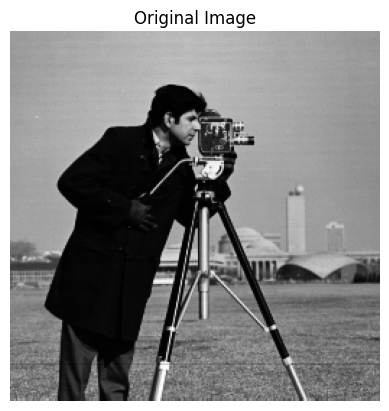

Shakey raw values [[156 159 158 ... 151 152 152]
 [160 154 157 ... 154 155 153]
 [156 159 158 ... 151 152 152]
 ...
 [114 132 123 ... 135 137 114]
 [121 126 130 ... 133 130 113]
 [121 126 130 ... 133 130 113]]


In [6]:

# Read image
inputimg = skimage.io.imread('cameraman.png')

# Display the image
plt.imshow(inputimg,cmap="gray")
plt.title("Original Image")
plt.axis('off')
plt.show()

print("Shakey raw values", inputimg)

In scikit we perform convolution using the convolve2d function. Kernels can be defined as numpy arrays as seen below. A detailed guide to this function can be found here: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve2d.html

In [7]:
sobel_x = np.array(
    [[1,0,-1],
     [2,0,-2],
     [1,0,-1]])

sobel_y = np.array(
    [[1,2,1],
     [0,0,0],
     [-1,-2,-1]])

print(sobel_y)

[[ 1  2  1]
 [ 0  0  0]
 [-1 -2 -1]]


X-gradient values:
[[156 159   2 ...   1 152 152]
 [472 472   1 ...   1 459 457]
 [632 626   2 ...   0 614 610]
 ...
 [477 510  36 ...  81 527 453]
 [363 378  27 ...  60 390 339]
 [121 126   9 ...  20 130 113]]


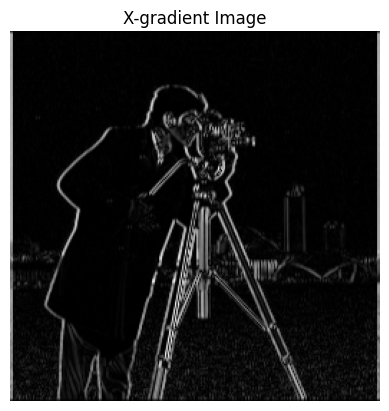

In [8]:
# Applying a filter
# We convert the output type to floats in order to preserve negative gradients
# We can also threshold the image using the > operator
output_sobel_x = abs(scipy.signal.convolve2d(inputimg,sobel_x))#>50

print("X-gradient values:")
print(output_sobel_x)

# Here we use the binary helper function as our image is now binary
#show_binary_image(output_sobel_x)
plt.imshow(output_sobel_x,cmap="gray")
plt.title("X-gradient Image")
plt.axis('off')
plt.show()

# We can also threshold the image using the > operator
#threshold_shakey_sobel_x = abs(scipy.signal.convolve2d(inputimg, sobel_x))>50
# Try to apply the threshold operation and visualize the results

# Task1

Combine the two resulting arrays (output_sobel_x and output_sobel_y) to compute the magnitude. To do this, you will have to make your own function, such that:

```m = magnitude(x,y)```

In the same way, create a function to compute the direction of the magnitude.

Display the resulting magnitude and orientation images. 


Also, display the resulting edge image after thresholding it and consider different thresholds.

**QUESTION 1: What do you notice regarding the effect of changing the threshold? State both your observations and the reasons for the observations. Show your code, results and answer in the report.**

*Answer: The overall observation is that as the threshold value is decreased (from an unknown value, to 50, and then to 20), the area covered by white pixels the "white spots"gradually increases.
When you decrease the threshold value, you expand the range of pixel intensities that satisfy the condition >Threshold.*

*Since a lower threshold includes a larger set of original pixel intensity values, more pixels will be converted to white, leading to an increase in the size and quantity of the "white spots" or foreground objects. The image becomes brighter or "whiter" as the threshold is lowered.*

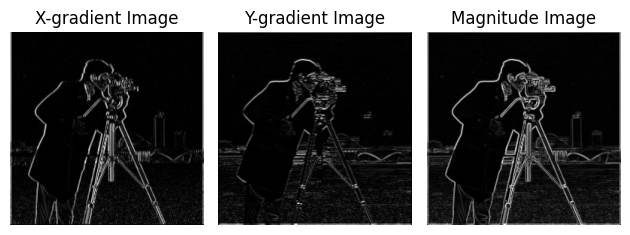

In [9]:
# Complete Task 1 here
output_sobel_x = abs(scipy.signal.convolve2d(inputimg, sobel_x))#>50
output_sobel_y = abs(scipy.signal.convolve2d(inputimg, sobel_y))#>50

# Here we use the binary helper function as our image is now binary
#show_binary_image(output_sobel_x)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
#print("X-gradient values:")
#print(output_sobel_x)
plt.imshow(output_sobel_x,cmap="gray")
plt.title("X-gradient Image")
plt.axis('off')

#print("Y-gradient values:")
#print(output_sobel_y)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,2)
plt.imshow(output_sobel_y,cmap="gray")
plt.title("Y-gradient Image")
plt.axis('off')
##output Y

#function compute the magnitude and direction
def magnitude(x,y):
    return np.sqrt(x**2+y**2)
#function to compute the direction of the magnitude
def direction(x,y):
    return np.arctan2(y,x)
#compute the magnitude and direction
magnitude_img=magnitude(output_sobel_x,output_sobel_y)
direction_img=direction(output_sobel_x,output_sobel_y)

#display magnitude and direction
plt.subplot(1,3,3)
#plt.figure(figsize=(15,5))
plt.imshow(magnitude_img,cmap="gray")
plt.title("Magnitude Image")
plt.axis('off')
plt.tight_layout()
plt.show()



正在使用阈值: [30, 50, 80, 100] 对幅值图像进行二值化...


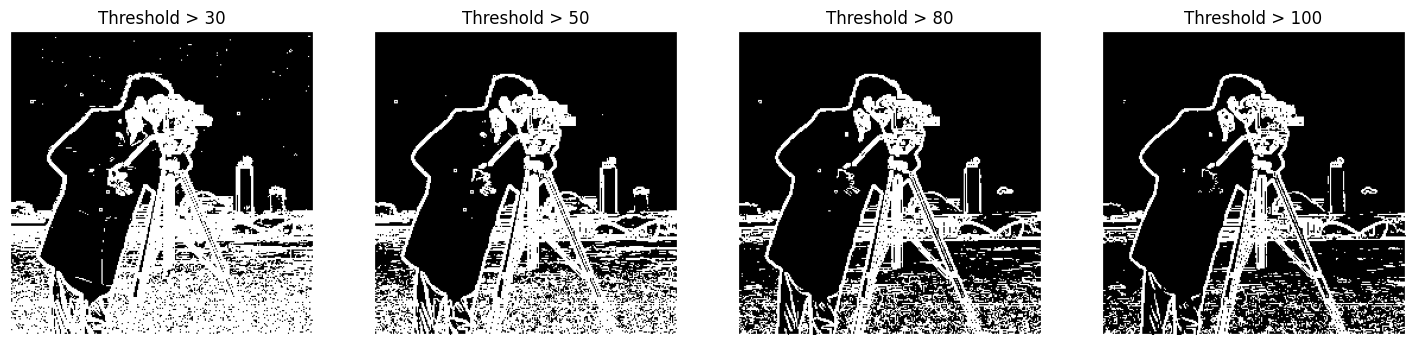

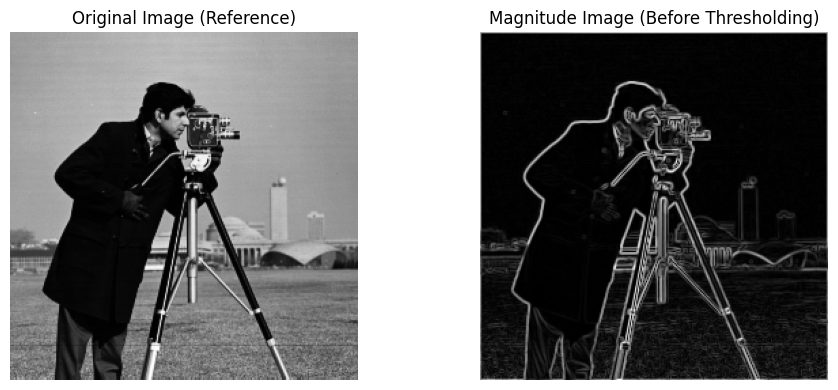

In [10]:
# Complete Task 1 here
from scipy import signal

output_sobel_x = signal.convolve2d(inputimg, sobel_x, mode='same')
output_sobel_y = signal.convolve2d(inputimg, sobel_y, mode='same')

# 计算梯度幅值
def magnitude(x, y):
    return np.sqrt(x**2 + y**2)

magnitude_img = magnitude(output_sobel_x, output_sobel_y)

# --- 3. 循环设置阈值并显示二值化结果 ---
thresholds = [30, 50, 80, 100] # 要测试的阈值列表
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 4)) # 创建子图布局

print(f"正在使用阈值: {thresholds} 对幅值图像进行二值化...")

for i, threshold in enumerate(thresholds):
    
    # **核心操作：阈值化**
    # 设定条件：如果幅值 > 阈值，则为白色(255)，否则为黑色(0)
    binary_edge_img = np.where(magnitude_img > threshold, 255, 0).astype(np.uint8)
    
    # 绘图
    ax = axes[i]
    ax.imshow(binary_edge_img, cmap="gray")
    ax.set_title(f"Threshold > {threshold}")
    ax.axis('off')

# 显示原始图像和幅值图像作为参考
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(inputimg, cmap='gray')
plt.title("Original Image (Reference)")
plt.axis('off')

plt.subplot(1, 2, 2)
# 对幅值图像进行归一化显示，以便于观察其灰度变化
plt.imshow(magnitude_img, cmap='gray')
plt.title("Magnitude Image (Before Thresholding)")
plt.axis('off')

plt.tight_layout()
plt.show()



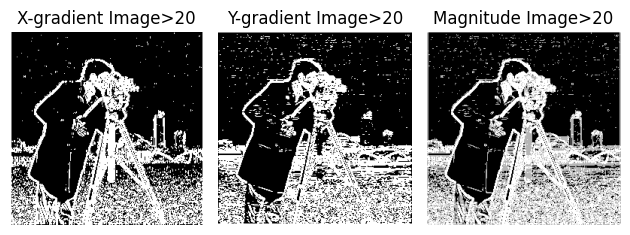

In [41]:
# Complete Task 1 here
threshold_shakey_sobel_x = abs(scipy.signal.convolve2d(inputimg, sobel_x))>20
threshold_shakey_sobel_y = abs(scipy.signal.convolve2d(inputimg, sobel_y))>20

# Here we use the binary helper function as our image is now binary
#show_binary_image(threshold_shakey_sobel_x)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
#print("X-gradient values:")
#print(threshold_shakey_sobel_x)
plt.imshow(threshold_shakey_sobel_x,cmap="gray")
plt.title("X-gradient Image>20")
plt.axis('off')

#print("Y-gradient values:")
#print(threshold_shakey_sobel_y)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,2)
plt.imshow(threshold_shakey_sobel_y,cmap="gray")
plt.title("Y-gradient Image>20")
plt.axis('off')
##output Y

#function compute the magnitude and direction
def magnitude(x,y):
    return np.sqrt(x**2+y**2)
#function to compute the direction of the magnitude
def direction(x,y):
    return np.arctan2(y,x)
#compute the magnitude and direction
magnitude_img=magnitude(threshold_shakey_sobel_x,threshold_shakey_sobel_y)
direction_img=direction(threshold_shakey_sobel_x,threshold_shakey_sobel_y)

#display magnitude and direction
plt.subplot(1,3,3)
#plt.figure(figsize=(15,5))
plt.imshow(magnitude_img,cmap="gray")
plt.title("Magnitude Image>20")
plt.axis('off')
plt.tight_layout()
plt.show()



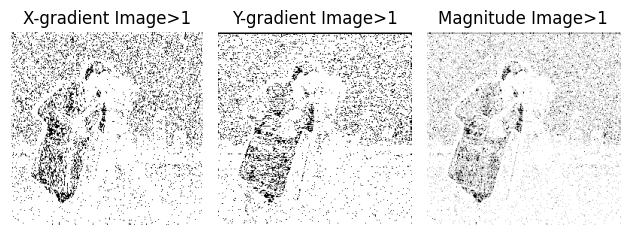

In [40]:
# Complete Task 1 here
threshold_shakey_sobel_x = abs(scipy.signal.convolve2d(inputimg, sobel_x))>1
threshold_shakey_sobel_y = abs(scipy.signal.convolve2d(inputimg, sobel_y))>1

# Here we use the binary helper function as our image is now binary
#show_binary_image(threshold_shakey_sobel_x)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
#print("X-gradient values:")
#print(threshold_shakey_sobel_x)
plt.imshow(threshold_shakey_sobel_x,cmap="gray")
plt.title("X-gradient Image>1")
plt.axis('off')

#print("Y-gradient values:")
#print(threshold_shakey_sobel_y)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,2)
plt.imshow(threshold_shakey_sobel_y,cmap="gray")
plt.title("Y-gradient Image>1")
plt.axis('off')
##output Y

#function compute the magnitude and direction
def magnitude(x,y):
    return np.sqrt(x**2+y**2)
#function to compute the direction of the magnitude
def direction(x,y):
    return np.arctan2(y,x)
#compute the magnitude and direction
magnitude_img=magnitude(threshold_shakey_sobel_x,threshold_shakey_sobel_y)
direction_img=direction(threshold_shakey_sobel_x,threshold_shakey_sobel_y)

#display magnitude and direction
plt.subplot(1,3,3)
#plt.figure(figsize=(15,5))
plt.imshow(magnitude_img,cmap="gray")
plt.title("Magnitude Image>1")
plt.axis('off')
plt.tight_layout()
plt.show()



# Task 2

Repeat your previous exercise, with the Prewitt operator (see the lecture slides).


**QUESTION 2: What do you notice regarding the difference between Sobel and Prewitt? State both your observations and the reasons for the observations.**

[[-1  0  1]
 [-1  0  1]
 [-1  0  1]]


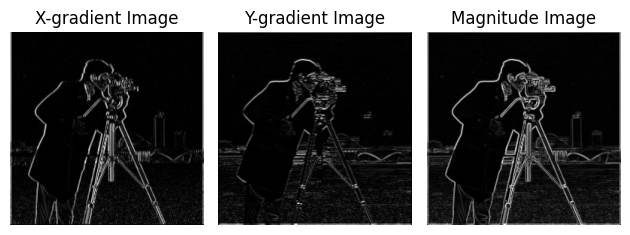

In [13]:
# Complete Task 2 here
Prewitt_x = np.array(
    [[-1,-1,-1],
     [0,0,0],
     [1,1,1]])

Prewitt_y = np.array(
    [[-1,0,1],
     [-1,0,1],
     [-1,0,1]])

print(Prewitt_y)
output_sobel_x = abs(scipy.signal.convolve2d(inputimg, sobel_x))#>50
output_sobel_y = abs(scipy.signal.convolve2d(inputimg, sobel_y))#>50

# Here we use the binary helper function as our image is now binary
#show_binary_image(output_sobel_x)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
#print("X-gradient values:")
#print(output_sobel_x)
plt.imshow(output_sobel_x,cmap="gray")
plt.title("X-gradient Image")
plt.axis('off')

#print("Y-gradient values:")
#print(output_sobel_y)
#plt.figure(figsize=(15,5))
plt.subplot(1,3,2)
plt.imshow(output_sobel_y,cmap="gray")
plt.title("Y-gradient Image")
plt.axis('off')
##output Y

#function compute the magnitude and direction
def magnitude(x,y):
    return np.sqrt(x**2+y**2)
#function to compute the direction of the magnitude
def direction(x,y):
    return np.arctan2(y,x)
#compute the magnitude and direction
magnitude_img=magnitude(output_sobel_x,output_sobel_y)
direction_img=direction(output_sobel_x,output_sobel_y)

#display magnitude and direction
plt.subplot(1,3,3)
#plt.figure(figsize=(15,5))
plt.imshow(magnitude_img,cmap="gray")
plt.title("Magnitude Image")
plt.axis('off')
plt.tight_layout()
plt.show()

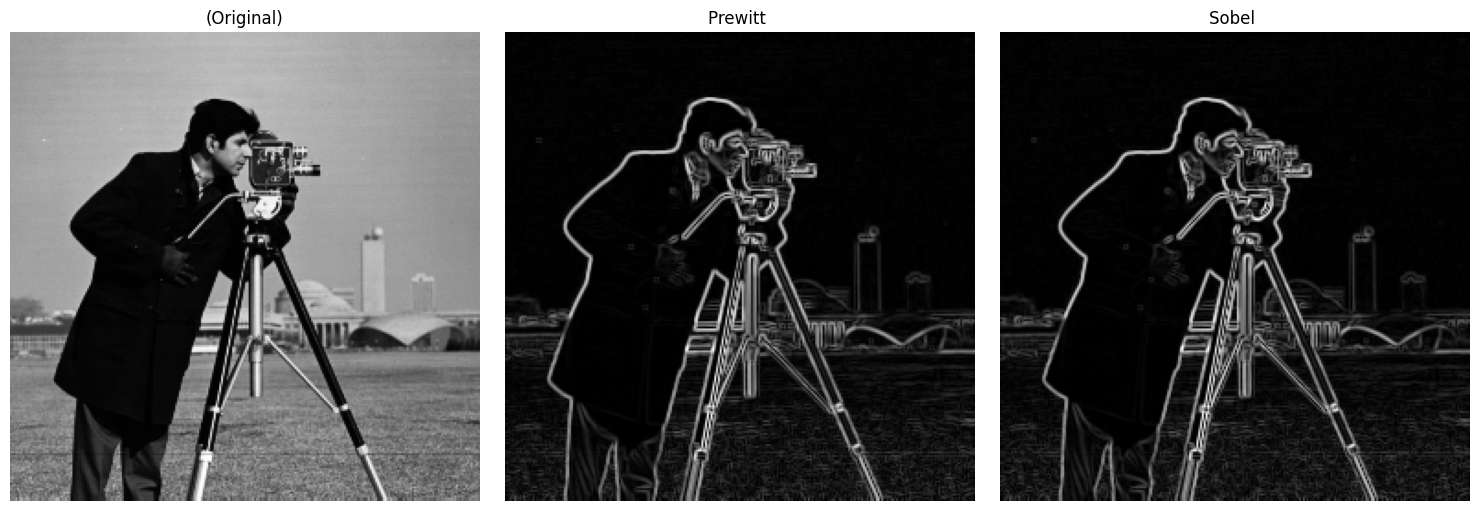


--- observation ---
1. 强度：Sobel 边缘通常比 Prewitt 边缘更亮（强度更高），这是因为 Sobel 对中心像素进行了加权 (权重 2)。
2. 平滑性/噪声：Sobel 边缘通常更连续、更平滑，因为它内置了轻微的平滑效果，可以更好地抑制孤立的噪声点。


In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 设置参数和加载图像 ---
# 请替换为您自己的图像路径！
# 建议选择一张包含清晰线条和一些平滑区域的图片，以便观察差异
image_path = 'cameraman.png' 

# 尝试加载图片
try:
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"无法加载图片: {image_path}")
except FileNotFoundError as e:
    print(e)
    print("注意：请将 'your_image_path.jpg' 替换为有效的图片路径。")
    # 如果找不到图片，我们创建一个简单的合成图片作为演示
    img = np.zeros((100, 100), dtype=np.uint8)
    img[20:80, 20:80] = 200  # 创建一个灰色的方块
    img[50:60, 50:60] = 50   # 在中心添加一个暗点（模拟噪声或细节）
    print("已使用一个简单的合成图像进行演示。")

# 将图像转换为 float32 类型，以便进行浮点运算
img_float = np.float32(img)


# --- 2. Prewitt 算子实现 ---

# 定义 Prewitt 卷积核
# Gx (水平方向)
kernel_prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# Gy (垂直方向)
kernel_prewitt_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
], dtype=np.float32)

# 使用 cv2.filter2D 进行卷积操作
grad_prewitt_x = cv2.filter2D(img_float, -1, kernel_prewitt_x)
grad_prewitt_y = cv2.filter2D(img_float, -1, kernel_prewitt_y)

# 计算梯度幅值 (Magnitude)
# G = sqrt(Gx^2 + Gy^2)
prewitt_magnitude = cv2.magnitude(grad_prewitt_x, grad_prewitt_y)
# 归一化到 0-255 范围
prewitt_result = cv2.normalize(prewitt_magnitude, None, 0, 255, cv2.NORM_MINMAX)
prewitt_result = np.uint8(prewitt_result)


# --- 3. Sobel 算子实现 ---

# Sobel 算子可以直接使用 cv2.Sobel
# ksize=3 表示 3x3 卷积核
# dx=1, dy=0 计算 x 方向梯度 (Gx)
grad_sobel_x = cv2.Sobel(img_float, cv2.CV_32F, 1, 0, ksize=3)
# dx=0, dy=1 计算 y 方向梯度 (Gy)
grad_sobel_y = cv2.Sobel(img_float, cv2.CV_32F, 0, 1, ksize=3)

# 计算梯度幅值 (Magnitude)
sobel_magnitude = cv2.magnitude(grad_sobel_x, grad_sobel_y)
# 归一化到 0-255 范围
sobel_result = cv2.normalize(sobel_magnitude, None, 0, 255, cv2.NORM_MINMAX)
sobel_result = np.uint8(sobel_result)


# --- 4. 可视化对比结果 ---

plt.figure(figsize=(15, 5))

# 原始图像
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('(Original)')
plt.axis('off')

# Prewitt 结果
plt.subplot(1, 3, 2)
plt.imshow(prewitt_result, cmap='gray')
plt.title('Prewitt ')
plt.axis('off')

# Sobel 结果
plt.subplot(1, 3, 3)
plt.imshow(sobel_result, cmap='gray')
plt.title('Sobel ')
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n--- observation ---")
print("1. 强度：Sobel 边缘通常比 Prewitt 边缘更亮（强度更高），这是因为 Sobel 对中心像素进行了加权 (权重 2)。")
print("2. 平滑性/噪声：Sobel 边缘通常更连续、更平滑，因为它内置了轻微的平滑效果，可以更好地抑制孤立的噪声点。")

# Task 3

You have to implement the Laplacian operator with and without diagonals. 

**QUESTION 3: What do you notice regarding the difference between including or discarding diagonal coefficients when calculating the edge?**
In summary, the 8-connected kernel ($\begin{pmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1 & 1 & 1 \end{pmatrix}$) provides a smoother, more comprehensive, and rotationally consistent edge response, while the 4-connected kernel ($\begin{pmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{pmatrix}$) gives a sharper, thinner, and often sparser result, primarily emphasizing vertical and horizontal changes.

正在使用阈值: [30, 50, 80, 100] 对幅值图像进行二值化...


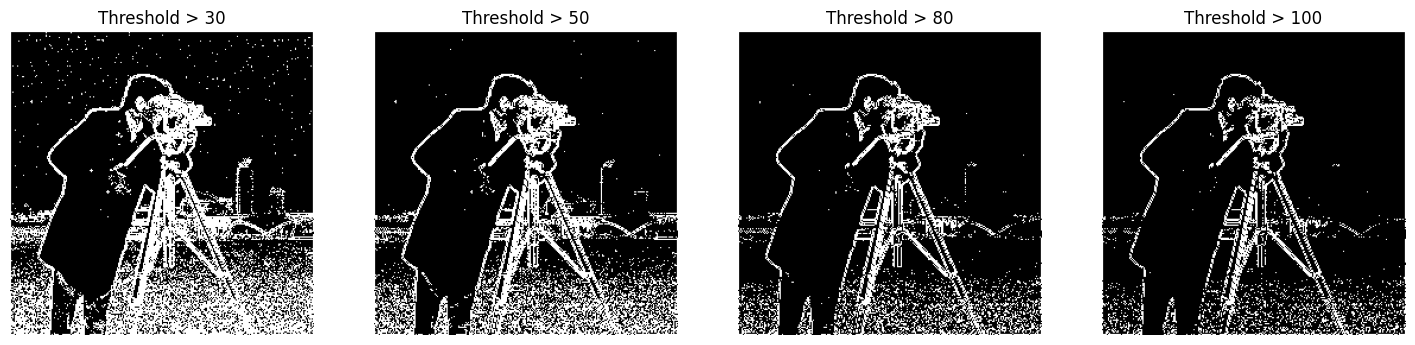

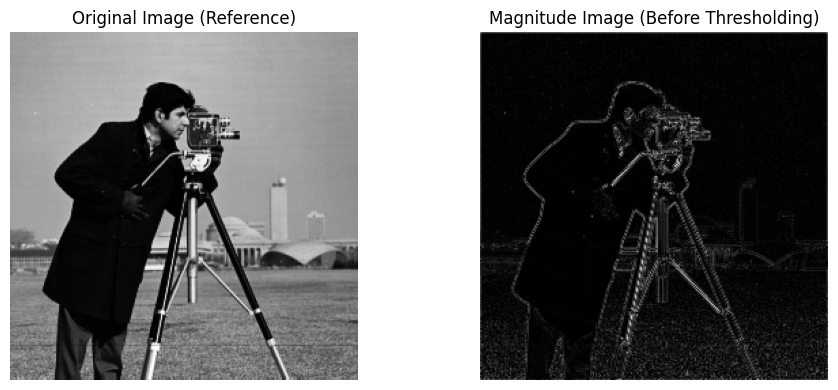

In [27]:
# Complete Task 3 hereLaplacian
from scipy import signal
Prewitt_x = np.array(
    [[0,1,0],
     [1,-4,1],
     [0,1,0]])
##Laplacian without diagonals
Prewitt_y = np.array(
    [[0,1,0],
     [1,-4,1],
     [0,1,0]])

##Prewitt_y = np.array(
    #[[1,1,1],
     #[1,-8,1],
     #[1,1,1]])
output_sobel_x = signal.convolve2d(inputimg, Prewitt_x, mode='same')
output_sobel_y = signal.convolve2d(inputimg, Prewitt_y, mode='same')

# 计算梯度幅值
def magnitude(x, y):
    return np.sqrt(x**2 + y**2)

magnitude_img = magnitude(output_sobel_x, output_sobel_y)

# --- 3. 循环设置阈值并显示二值化结果 ---

thresholds = [30, 50, 80, 100] # 要测试的阈值列表
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 4)) # 创建子图布局

print(f"正在使用阈值: {thresholds} 对幅值图像进行二值化...")

for i, threshold in enumerate(thresholds):
    
    # **核心操作：阈值化**
    # 设定条件：如果幅值 > 阈值，则为白色(255)，否则为黑色(0)
    binary_edge_img = np.where(magnitude_img > threshold, 255, 0).astype(np.uint8)
    
    # 绘图
    ax = axes[i]
    ax.imshow(binary_edge_img, cmap="gray")
    ax.set_title(f"Threshold > {threshold}")
    ax.axis('off')

# 显示原始图像和幅值图像作为参考
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(inputimg, cmap='gray')
plt.title("Original Image (Reference)")
plt.axis('off')

plt.subplot(1, 2, 2)
# 对幅值图像进行归一化显示，以便于观察其灰度变化
plt.imshow(magnitude_img, cmap='gray')
plt.title("Magnitude Image (Before Thresholding)")
plt.axis('off')

plt.tight_layout()
plt.show()

正在使用阈值: [30, 50, 80, 100] 对幅值图像进行二值化...


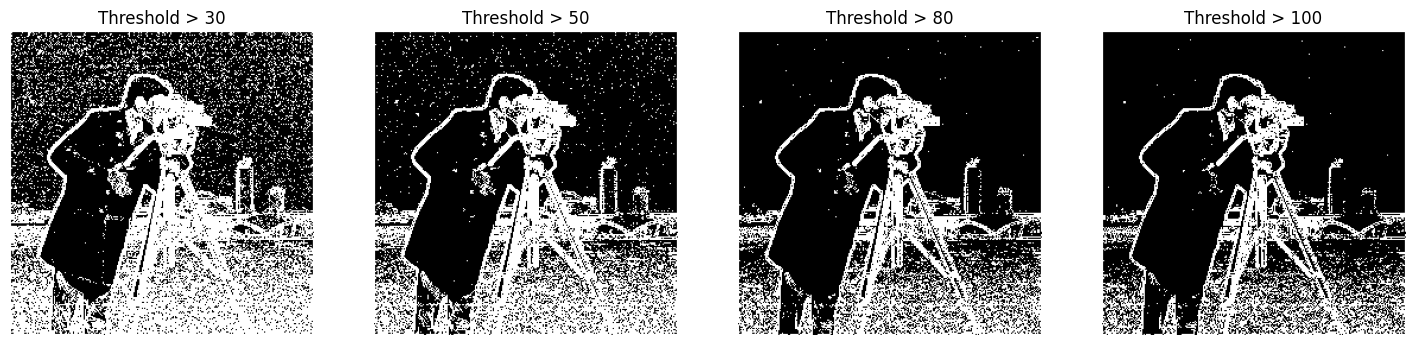

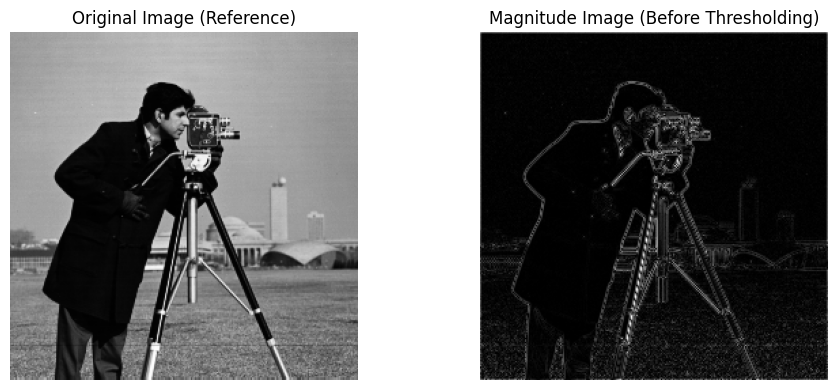

In [11]:
# Complete Task 3 hereLaplacian
from scipy import signal
##Laplacian with diagonals
Prewitt_x = np.array(
    [[1,1,1],
     [1,-8,1],
     [1,1,1]])
Prewitt_y = np.array(
    [[1,1,1],
     [1,-8,1],
     [1,1,1]])
output_sobel_x = signal.convolve2d(inputimg, Prewitt_x, mode='same')
output_sobel_y = signal.convolve2d(inputimg, Prewitt_y, mode='same')

# 计算梯度幅值
def magnitude(x, y):
    return np.sqrt(x**2 + y**2)

magnitude_img = magnitude(output_sobel_x, output_sobel_y)

# --- 3. 循环设置阈值并显示二值化结果 ---

thresholds = [30, 50, 80, 100] # 要测试的阈值列表
fig, axes = plt.subplots(1, len(thresholds), figsize=(18, 4)) # 创建子图布局

print(f"正在使用阈值: {thresholds} 对幅值图像进行二值化...")

for i, threshold in enumerate(thresholds):
    
    # **核心操作：阈值化**
    # 设定条件：如果幅值 > 阈值，则为白色(255)，否则为黑色(0)
    binary_edge_img = np.where(magnitude_img > threshold, 255, 0).astype(np.uint8)
    
    # 绘图
    ax = axes[i]
    ax.imshow(binary_edge_img, cmap="gray")
    ax.set_title(f"Threshold > {threshold}")
    ax.axis('off')

# 显示原始图像和幅值图像作为参考
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(inputimg, cmap='gray')
plt.title("Original Image (Reference)")
plt.axis('off')

plt.subplot(1, 2, 2)
# 对幅值图像进行归一化显示，以便于观察其灰度变化
plt.imshow(magnitude_img, cmap='gray')
plt.title("Magnitude Image (Before Thresholding)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Task 4
Reutilising the Gaussian filter you constructed in the previous lab session, implement the Canny edge detector. Remember to define $\theta_2 = 2*\theta_1$ or greater.
Compare the results against Sobel and Prewitt

**QUESTION 4: What do you observe about the different detected edge orientations? Which technique seems to be less sensitive to spurious edges?**

*The technique that seems to be less sensitive to spurious edges (false edges caused by noise) is the Canny Edge Detector.*

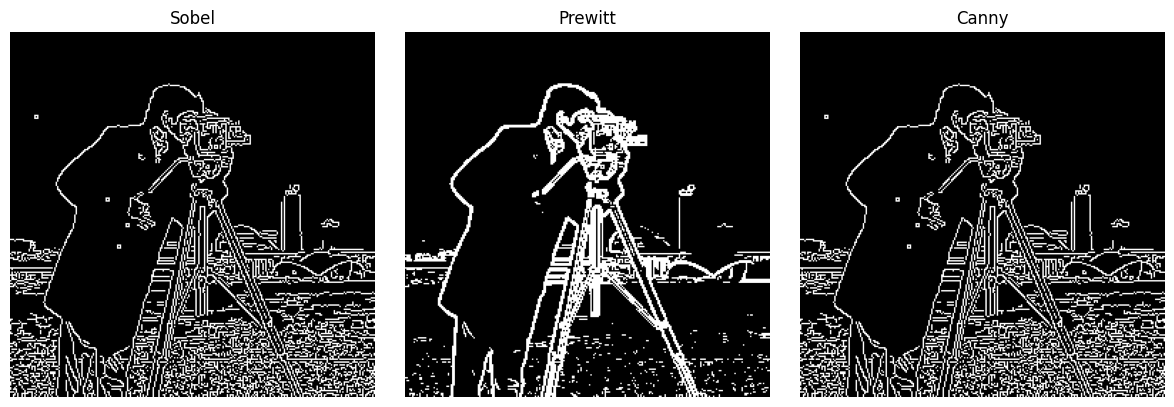

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters,feature,color,io

image = io.imread('cameraman.png')
# 假设的原图和高斯平滑结果（请根据您的实际环境替换）
# 假设 'img' 和 'img_gaussian_filtered' 已经存在且是浮点/归一化类型。
if len(image.shape)==3:
    img=color.rgb2grey(image)
else:
    img= image.astype(np.float64)/255.0

edges_soble=filters.sobel(image)
edges_prewitt=filters.prewitt(image)

x1=40
x2=2*x1

edges_canny=feature.canny(image,sigma=1.0,
                         low_threshold=x1/255, high_threshold=x2/255,)

# ---  Canny 边缘检测实现 ---
# 设置双阈值。经验法则：高阈值 = 2 * 低阈值。
canny_result = cv2.Canny(img_for_canny, low_threshold, high_threshold, apertureSize=3)


# ---可视化结果进行比较 ---

plt.figure(figsize=(12, 4))

#  结果
plt.subplot(1, 3, 1)
plt.title('Sobel')
plt.imshow(canny_result, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Prewitt')
plt.imshow(sobel_result_binary, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Canny')
plt.imshow(canny_result, cmap='gray')
plt.axis('off')


plt.tight_layout()
plt.show()